## Phase 1: Data Loading & Initial Exploration

This notebook loads the two raw datasets pulled from the NASA Exoplanet Archive:

- **`koi_cumulative.csv`** — Kepler Objects of Interest (KOI) cumulative table. Used for **Part A**: classifying CANDIDATE rows as likely real planets or false positives.
- **`confirmed_planets.csv`** — Planetary Systems Composite Parameters (PSCompPars) table, spanning Kepler + K2 + TESS + ground-based confirmations. Used for **Part B**: habitability scoring on confirmed + predicted-real planets.

This notebook covers: loading, shape/structure checks, target variable distribution, missing-value overview, and a first look at feature columns.

In [1]:
import pandas as pd

koi = pd.read_csv("../data/raw/koi_cumulative.csv", comment="#")
confirmed = pd.read_csv("../data/raw/confirmed_planets.csv", comment="#", low_memory=False)

print("KOI shape:", koi.shape)
print("Confirmed shape:", confirmed.shape)

KOI shape: (9564, 153)
Confirmed shape: (6366, 703)


In [2]:
koi.head()

,kepid,kepoi_name,kepler_name,ra,ra_err,ra_str,dec,dec_err,dec_str,koi_gmag,...,koi_fpflag_co,koi_fpflag_ec,koi_insol,koi_insol_err1,koi_insol_err2,koi_srho,koi_srho_err1,koi_srho_err2,koi_fittype,koi_score
0,10797460,K00752.01,Kepler-227 b,291.93423,0.0,19h27m44.22s,48.141651,0.0,+48d08m29.9s,15.890,...,0,0,93.59,29.45,-16.65,3.20796,0.33173,-1.09986,LS+MCMC,1.000
1,10797460,K00752.02,Kepler-227 c,291.93423,0.0,19h27m44.22s,48.141651,0.0,+48d08m29.9s,15.890,...,0,0,9.11,2.87,-1.62,3.02368,2.20489,-2.49638,LS+MCMC,0.969
2,10811496,K00753.01,NaN,297.00482,0.0,19h48m01.16s,48.134129,0.0,+48d08m02.9s,15.943,...,0,0,39.30,31.04,-10.49,7.29555,35.03293,-2.75453,LS+MCMC,0.000
3,10848459,K00754.01,NaN,285.53461,0.0,19h02m08.31s,48.285210,0.0,+48d17m06.8s,16.100,...,0,0,891.96,668.95,-230.35,0.22080,0.00917,-0.01837,LS+MCMC,0.000
4,10854555,K00755.01,Kepler-664 b,288.75488,0.0,19h15m01.17s,48.226200,0.0,+48d13m34.3s,16.015,...,0,0,926.16,874.33,-314.24,1.98635,2.71141,-1.74541,LS+MCMC,1.000


In [3]:
confirmed.head()

,systemid,sy_name,objectid,pl_name,pl_letter,hostid,hostname,hd_name,hip_name,tic_id,...,pl_tsm_solnid,pl_tsmstr,pl_tsmlim,pl_esm,pl_esmerr1,pl_esmerr2,pl_esm_reflink,pl_esm_solnid,pl_esmstr,pl_esmlim
0,1.539830,HD 2039,3.11204,HD 2039 b,b,2.539830,HD 2039,HD 2039,HIP 1931,TIC 281461362,...,NaN,NaN,NaN,0.1,NaN,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,NaN,0.0,0.0
1,1.103446,HAT-P-8,3.11027,HAT-P-8 b,b,2.103446,HAT-P-8,NaN,NaN,TIC 188876052,...,NaN,109.0,0.0,120.0,NaN,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,NaN,120.0,0.0
2,1.643080,K2-43,3.88640,K2-43 b,b,2.643080,K2-43,NaN,NaN,TIC 443616612,...,NaN,60.0,0.0,14.5,NaN,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,NaN,15.0,0.0
3,1.567687,Kepler-1753,3.15620,Kepler-1753 b,b,2.567687,Kepler-1753,NaN,NaN,TIC 158664331,...,NaN,4.0,0.0,0.1,NaN,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,NaN,0.0,0.0
4,1.544946,Kepler-1176,3.24120,Kepler-1176 b,b,2.544946,Kepler-1176,NaN,NaN,TIC 273582656,...,NaN,3.0,0.0,0.1,NaN,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,NaN,0.0,0.0


### Target Variable — `koi_disposition`

This is the label for Part A. Checking the class balance up front.

In [4]:
koi["koi_disposition"].value_counts()

koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2748
CANDIDATE         1977
Name: count, dtype: int64

### Missing Value Overview

With 153 columns (KOI) and 703 columns (confirmed planets), many are likely sparse or irrelevant. This is a first pass to identify what to drop later.

In [5]:
koi.isnull().sum().sort_values(ascending=False).head(20)

koi_gmag_err        9564
koi_imag_err        9564
koi_zmag_err        9564
koi_rmag_err        9564
koi_kepmag_err      9564
koi_longp_err2      9564
koi_sage_err2       9564
koi_sage_err1       9564
koi_sage            9564
koi_sma_err1        9564
koi_sma_err2        9564
koi_ingress_err1    9564
koi_ingress         9564
koi_ingress_err2    9564
koi_incl_err2       9564
koi_teq_err1        9564
koi_teq_err2        9564
koi_incl_err1       9564
koi_model_dof       9564
koi_eccen_err1      9564
dtype: int64

In [6]:
confirmed.isnull().sum().sort_values(ascending=False).head(20)

pl_angsepformat     6366
pl_esm_solnid       6366
pl_esmerr2          6366
pl_esmerr1          6366
pl_angsepsymerr     6366
pl_angsep_solnid    6366
st_densformat       6366
st_lumformat        6366
sy_w4maglim         6366
sy_w4magformat      6366
sy_icmagformat      6366
sy_gmaglim          6366
st_vsinformat       6366
st_rotpformat       6366
st_metformat        6366
st_metn             6366
st_radvformat       6366
st_log_rhkformat    6366
st_radformat        6366
sy_pmlim            6366
dtype: int64

### Column Audit

Separating KOI columns into rough categories: identifiers/labels, core features, and error-margin columns (often dropped or handled separately in modeling).

In [7]:
id_labels_cols = ["kepid", "kepoi_name", "kepler_name", "koi_disposition", "koi_pdisposition", "koi_score"]
err_cols = [c for c in koi.columns if c.endswith("_err1") or c.endswith("_err2") or c.endswith("_err")]
feature_cols = [c for c in koi.columns if c not in id_labels_cols and c not in err_cols]

print(f"ID/label columns: {len(id_labels_cols)}")
print(f"ID/Error-margin columns: {len(err_cols)}")
print(f"ID/Candidate feature columns: {len(feature_cols)}")

ID/label columns: 6
ID/Error-margin columns: 68
ID/Candidate feature columns: 79


### Quick Sanity Distributions

Eyeballing a few key physical features for obvious grabage (negative values, extreme outliers) before deeper cleaning.

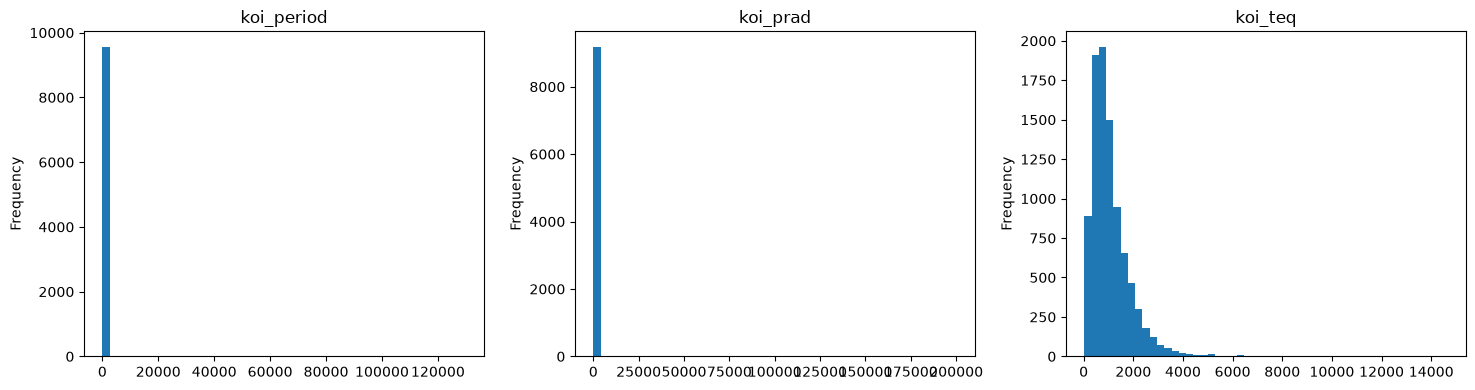

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
koi["koi_period"].dropna().plot(kind="hist", bins=50, ax=axes[0], title="koi_period")
koi["koi_prad"].dropna().plot(kind="hist", bins=50, ax=axes[1], title="koi_prad")
koi["koi_teq"].dropna().plot(kind="hist", bins=50, ax=axes[2], title="koi_teq")
plt.tight_layout()
plt.show()

In [9]:
feature_nulls = koi[feature_cols].isnull().sum().sort_values(ascending=False)
feature_nulls.head(20)

koi_ingress         9564
koi_model_chisq     9564
koi_sage            9564
koi_longp           9564
koi_model_dof       9564
koi_bin_oedp_sig    1510
koi_comment         1209
koi_max_sngle_ev    1142
koi_quarters        1142
koi_num_transits    1142
koi_max_mult_ev     1142
koi_fwm_stat_sig    1076
koi_fwm_prao         830
koi_fwm_pdeco        817
koi_zmag             613
koi_dicco_mdec       599
koi_dicco_mra        599
koi_dicco_msky       599
koi_dikco_msky       570
koi_dikco_mdec       570
dtype: int64

### Next Steps

Phase 2 will cover cleaning and feature selection for Part A: handling missing values in the candidate feature set, dropping error-margin and identifier columns as appropriate, and preparing the data for the classification models.